In [1]:
import tensorflow as tf
import pathlib
import matplotlib.pyplot as plt
import os
import numpy as np
from dotenv import load_dotenv

"""
1) Buscar as máscaras - OK
2) Carregar e pré-processar as máscaras - OK
3) Criar pipeline para Aumento de Dados - OK
4) Configurar um dataset baseado nas máscaras - OK
5) Formular um treinamento - PENDENTE
6) Visualizar imagens - OK
"""

### 1. Configurar o caminho e criar lista de imagens ###
load_dotenv()

img_dir = os.getenv("BASE_IMG_FOLDER")
img_dir = pathlib.Path(img_dir)
mask_dir = os.getenv("NUMPY_FOLDER")
mask_dir = pathlib.Path(mask_dir)

# Verificar se o diretório existe
if not os.path.exists(mask_dir):
    raise ValueError(f"Diretório não encontrado: {mask_dir}")

# Função para extrair o número do nome do arquivo
def get_file_number(filepath):
    return int(os.path.basename(filepath).replace('.png', ''))
def get_file_number_mask(filepath):
    return int(os.path.basename(filepath).replace('.npy', ''))

# Verificar se os arquivos existem e converter PosixPath para strings 
mask_files = []
for path in mask_dir.glob('*.npy'):
    if os.path.exists(path):
        mask_files.append(str(path))

image_files = []
for path in img_dir.glob('*.png'):
    if os.path.exists(path):
        image_files.append(str(path))

# Ordenar a lista usando o número do arquivo como chave
image_files = sorted(image_files, key=get_file_number)
mask_files = sorted(mask_files, key=get_file_number_mask)

if len(image_files) != len(mask_files):
    raise ValueError("O número de imagens e máscaras não corresponde")

mask_count = len(mask_files)
print(f"Encontradas {mask_count} máscaras")

# Verificar se temos imagens
if mask_count == 0:
    raise ValueError(f"Nenhuma imagem PNG encontrada em: {mask_dir}")

# Mostrar alguns caminhos de exemplo
print("\nPrimeiros 5 caminhos de máscaras:")
for path in mask_files[:5]:
    print(path)

2025-02-10 10:39:17.414277: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Encontradas 5036 máscaras

Primeiros 5 caminhos de máscaras:
/media/renato/Data/PIBIC/NumpyFiles/000.npy
/media/renato/Data/PIBIC/NumpyFiles/001.npy
/media/renato/Data/PIBIC/NumpyFiles/002.npy
/media/renato/Data/PIBIC/NumpyFiles/003.npy
/media/renato/Data/PIBIC/NumpyFiles/004.npy


In [2]:
import numpy as np
# Linux
mask = np.load(r'/media/renato/Data/PIBIC/NumpyFiles/000.npy')

# Windows
# mask = np.load('C:\\Users\\Renato\\Documents\\PIBIC\\NumpyFiles\\2750.npy')

In [3]:
mask.shape

(512, 512, 22)

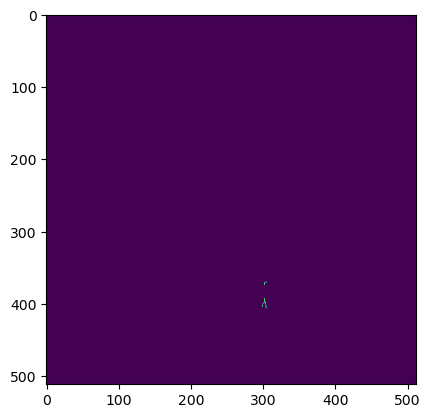

In [6]:
plt.imshow(mask[:,:,13])

In [7]:
def load_and_preprocess_image_mask(image_path, mask_path):
    try:
        # Carregar imagem RGB
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [256, 256])  # Redimensionar o tamanho
        img = tf.cast(img, tf.float32) / 255.0  # Normalizar a imagem

        # Carregar máscara do arquivo numpy
        mask = np.load(mask_path.numpy().decode())  # Ler a máscara
        mask = tf.convert_to_tensor(mask, dtype=tf.float32)  # Converter como tensor

        # Normalizar máscara
        mask = mask / 255.0  # Converter valores de 0-255 a 0-1

        return img, mask
    except Exception as e:
        print(f"Erro ao processar imagem/máscara {image_path}, {mask_path}: {str(e)}")
        raise


## Função para aplicar aumento de dados considerando máscaras como arrays multicamadas
def augment_image_mask(image, mask):
    # Gere um valor aleatório comum para transformações
    flip_left_right = tf.random.uniform(shape=[]) > 0.5
    flip_up_down = tf.random.uniform(shape=[]) > 0.5
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)  # 0, 90, 180, 270 graus

    # Flip horizontal
    if flip_left_right:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Flip vertical
    if flip_up_down:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # Aplicar rotação à imagem
    image = tf.image.rot90(image, k=k)

    # Aplique rotação à máscara em toda a sua dimensão
    mask = tf.image.rot90(mask, k=k)  # Agora giramos a máscara inteira de uma vez

    # Configurações adicionais de imagem
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    return image, mask

# Converter listas de rotas em conjunto de dados do TensorFlow
def process_path(image_path, mask_path):
    img, mask = tf.py_function(load_and_preprocess_image_mask, [image_path, mask_path], [tf.float32, tf.float32])
    img.set_shape((256, 256, 3))  # Defina o tamanho esperado da imagem
    mask.set_shape((256, 256, 22))  # Defina o tamanho esperado da máscara
    return img, mask

# Criar um conjunto de dados a partir de listas de imagens e máscaras
train_dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
train_dataset = train_dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

# Aplicar Aumento de Dados
train_dataset = train_dataset.map(lambda img, mask: augment_image_mask(img, mask), num_parallel_calls=tf.data.AUTOTUNE)

# Configurar o conjunto de dados
BUFFER_SIZE = 100   # Talvez aumentar para 128 no futuro
BATCH_SIZE = 32     # Talvez aumentar para 64 no futuro

train_dataset = (
    train_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Inspecionar o conjunto de dados
for img, mask in train_dataset.take(1):
    print(f"Imagem em lote: {img.shape}")  # Esperado: (batch_size, 256, 256, 3)
    print(f"Máscara em lote: {mask.shape}")  # Esperado: (batch_size, 256, 256, 22)

Imagem em lote: (32, 256, 256, 3)
Máscara em lote: (32, 256, 256, 22)


2025-02-04 07:15:32.005921: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
def unet_multilabel(input_shape=(256, 256, 3), num_classes=22):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Encoder (Downsampling)
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)

    # Decoder (Upsampling)
    u5 = tf.keras.layers.UpSampling2D((2, 2))(c4)
    u5 = tf.keras.layers.Conv2D(256, (2, 2), activation='relu', padding='same')(u5)
    merge5 = tf.keras.layers.Concatenate()([u5, c3])

    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(merge5)
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    u6 = tf.keras.layers.UpSampling2D((2, 2))(c5)
    u6 = tf.keras.layers.Conv2D(128, (2, 2), activation='relu', padding='same')(u6)
    merge6 = tf.keras.layers.Concatenate()([u6, c2])

    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(merge6)
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c6)

    u7 = tf.keras.layers.UpSampling2D((2, 2))(c6)
    u7 = tf.keras.layers.Conv2D(64, (2, 2), activation='relu', padding='same')(u7)
    merge7 = tf.keras.layers.Concatenate()([u7, c1])

    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(merge7)
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    # Camada de saída com ativação sigmóide para classificação multirótulo
    outputs = tf.keras.layers.Conv2D(num_classes, (1, 1), activation='sigmoid')(c7)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# Criar o modelo
model = unet_multilabel()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    524,544 │ up_sampling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_8[0][0],   │
│ (Concatenate)       │ 512)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │  1,179,904 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_9[0][0]  

 Total params: 7,698,710 (29.37 MB)

 Trainable params: 7,698,710 (29.37 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=18),
                       tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

In [ ]:
for img, mask in train_dataset.take(1):
    print(f"Formato da máscara: {mask.shape}")  # Deve ser (256, 256, 22)
    print(f"Tipo de dados da máscara: {mask.dtype}")  # Deve ser float32
    print(f"Valores únicos na máscara: {tf.unique(tf.reshape(mask, [-1]))[0].numpy()}")  # Deve conter valores entre 0 a 1

Formato da máscara: (32, 256, 256, 22)
Tipo de dados da máscara: <dtype: 'float32'>
Valores únicos na máscara: [0. 1.]


In [ ]:
## Obter o número total de amostras no conjunto de dados sem lote prévio
dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
dataset_size = tf.data.experimental.cardinality(dataset).numpy()

# Definir proporções para treinar, validar e testar
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

# Mesclar o conjunto de dados antes de dividir
shuffled_dataset = dataset.shuffle(BUFFER_SIZE)

# Divida o conjunto de dados ANTES de aplicar o lote para evitar o problema de lote duplo
train_dataset = shuffled_dataset.take(train_size)
remaining_dataset = shuffled_dataset.skip(train_size)
val_dataset = remaining_dataset.take(val_size)
test_dataset = remaining_dataset.skip(val_size)

# Aplicar aumento de dados apenas ao conjunto de treinamento
train_dataset = train_dataset.map(lambda img, mask: augment_image_mask(img, mask), num_parallel_calls=tf.data.AUTOTUNE)

# Aplicar lote após divisão
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Confirmar os tamanhos do conjunto
print(f'Tamanho do conjunto de dados de treinamento: {train_size}')
print(f'Tamanho do conjunto de dados de validação: {val_size}')
print(f'Tamanho do conjunto de dados de avaliação: {test_size}')


Tamanho do conjunto de dados de treinamento: 4028
Tamanho do conjunto de dados de validação: 503
Tamanho do conjunto de dados de avaliação: 505


In [ ]:
for img, mask in train_dataset.take(1):
    print(f"Formato da imagem (lote): {img.shape}")  # Deve ser (BATCH_SIZE, 256, 256, 3)
    print(f"Formato da máscara (lote): {mask.shape}")  # Deve ser (BATCH_SIZE, 256, 256, 22)

Formato da imagem (lote): (32, 256, 256, 3)
Formato da máscara (lote): (32, 256, 256, 22)


2025-02-04 07:17:37.105487: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(filepath='best_model.h5', save_best_only=True, monitor='val_loss')
]

EPOCHS = 50

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50


2025-01-22 22:47:13.976539: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 536870912 exceeds 10% of free system memory.
2025-01-22 22:47:14.214723: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 536870912 exceeds 10% of free system memory.
2025-01-22 22:47:14.638166: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 268435456 exceeds 10% of free system memory.
2025-01-22 22:47:14.808649: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 268435456 exceeds 10% of free system memory.
2025-01-22 22:47:15.701815: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 268435456 exceeds 10% of free system memory.


126/126 ━━━━━━━━━━━━━━━━━━━━ 2343s 19s/step - accuracy: 0.2935 - loss: 0.2611 - mean_io_u: 0.4649 - val_accuracy: 0.7190 - val_loss: 0.0793 - val_mean_io_u: 0.4550
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2338s 19s/step - accuracy: 0.2812 - loss: 0.1058 - mean_io_u: 0.4649 - val_accuracy: 0.7243 - val_loss: 0.0741 - val_mean_io_u: 0.4548
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2335s 19s/step - accuracy: 0.2935 - loss: 0.1028 - mean_io_u: 0.4649 - val_accuracy: 0.7197 - val_loss: 0.0782 - val_mean_io_u: 0.4549
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2334s 19s/step - accuracy: 0.3049 - loss: 0.1016 - mean_io_u: 0.4649 - val_accuracy: 0.7293 - val_loss: 0.0570 - val_mean_io_u: 0.4547
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2329s 18s/step - accuracy: 0.3025 - loss: 0.1023 - mean_io_u: 0.4649 - val_accuracy: 0.7182 - val_loss: 0.0787 - val_mean_io_u: 0.4547
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2331s 18s/step - accuracy: 0.3041 - loss: 0.1019 - mean_io_u: 0.4649 - val_accuracy: 0.7278 - va

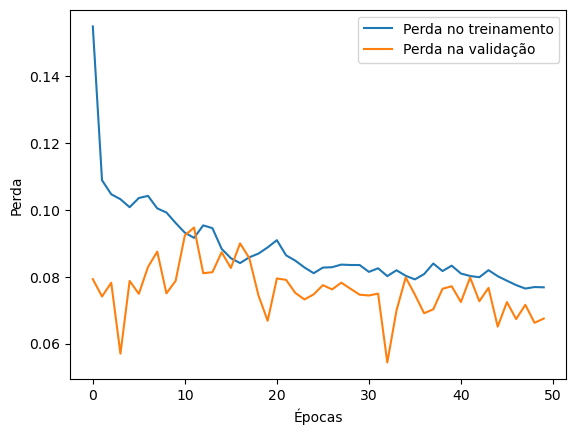

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Perda no treinamento')
plt.plot(history.history['val_loss'], label='Perda na validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()


In [14]:
import datetime
# Obtenha a data e hora atuais no formato YYYY-MM-DD_HH-MM-SS
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Crie um nome de arquivo com data e hora atuais
model_filename = f'segmentation_model_v1_{current_time}.h5'

# Salvar o modelo
model.save(model_filename)

print(f"Modelo salvo como: {model_filename}")

Modelo guardado como: modelo_segmentacion_2025-01-24_07-13-34.h5


In [15]:
import json

history_filename = f'history_v1_{current_time}.json'

# Salve o histórico de treinamento como um arquivo JSON
with open(history_filename, 'w') as f:
    json.dump(history.history, f)

print(f"Histórico salvo como: {history_filename}")

Modelo guardado como: modelo_segmentacion_2025-01-24_07-13-34.h5
Historial guardado como: history_2025-01-24_07-13-34.json


In [16]:
loss, accuracy, iou = model.evaluate(test_dataset)
print(f'Perda na avaliação: {loss}')
print(f'Precisão na avaliação: {accuracy}')
print(f'IoU em avaliação: {iou}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 116s 6s/step - accuracy: 0.7302 - loss: 0.0674 - mean_io_u: 0.4540
Pérdida en evaluación: 0.07056543231010437
Precisión en evaluación: 0.7331982254981995
IoU en evaluación: 0.4539543688297272


# 1st RETRAIN

In [10]:
# Carregar o modelo previamente treinado
model = tf.keras.models.load_model(
    'segmentation_model_v1_2025-01-24_07-13-34.h5', 
    custom_objects={'MeanIoU': tf.keras.metrics.MeanIoU}
)

print("Modelo carregado com sucesso.")
model.summary()

Modelo cargado exitosamente.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    524,544 │ up_sampling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_8[0][0],   │
│ (Concatenate)       │ 512)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │  1,179,904 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_9[0][0]  

 Total params: 7,698,452 (29.37 MB)

 Trainable params: 7,698,450 (29.37 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [20]:
# Configure um novo otimizador com uma taxa de aprendizado reduzida
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',  # Perda adequada para multilabel
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=22)]
)

# Defina o número adicional de épocas
EPOCHS_EXTRA = 25

history = model.fit(
    train_dataset,
    epochs=EPOCHS_EXTRA,
    validation_data=val_dataset,
    verbose=1
)

import datetime
# Obtenha a data e hora atuais no formato YYYY-MM-DD_HH-MM-SS
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Crie um nome de arquivo com data e hora atuais
model_filename = f'segmentation_model_v1_retrained{current_time}.h5'

# Salvar o modelo
model.save(model_filename)

print(f"Modelo salvo como: {model_filename}")

import json

history_filename = f'history_v1_retrained_{current_time}.json'

# Salve o histórico de treinamento como um arquivo JSON
with open(history_filename, 'w') as f:
    json.dump(history.history, f)

print(f"Histórico salvo como: {history_filename}")

Epoch 1/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 2378s 19s/step - accuracy: 0.4220 - loss: 0.0680 - mean_io_u: 0.4649 - val_accuracy: 0.7039 - val_loss: 0.0649 - val_mean_io_u: 0.4550
Epoch 2/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 2347s 19s/step - accuracy: 0.4094 - loss: 0.0697 - mean_io_u: 0.4649 - val_accuracy: 0.7003 - val_loss: 0.0653 - val_mean_io_u: 0.4549
Epoch 3/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 2351s 19s/step - accuracy: 0.4133 - loss: 0.0686 - mean_io_u: 0.4649 - val_accuracy: 0.7220 - val_loss: 0.0664 - val_mean_io_u: 0.4548
Epoch 4/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 2369s 19s/step - accuracy: 0.4117 - loss: 0.0691 - mean_io_u: 0.4649 - val_accuracy: 0.6798 - val_loss: 0.0657 - val_mean_io_u: 0.4551
Epoch 5/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 2365s 19s/step - accuracy: 0.4102 - loss: 0.0680 - mean_io_u: 0.4649 - val_accuracy: 0.6899 - val_loss: 0.0658 - val_mean_io_u: 0.4551
Epoch 6/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 2347s 19s/step - accuracy: 0.4271 - loss: 0.0644 - mean_io_u: 0.4649 - val_accuracy: 

Modelo guardado como: modelo_segmentacion_retrained_2025-01-25_03-44-47.h5
Historial guardado como: history_retrained_2025-01-25_03-44-47.json


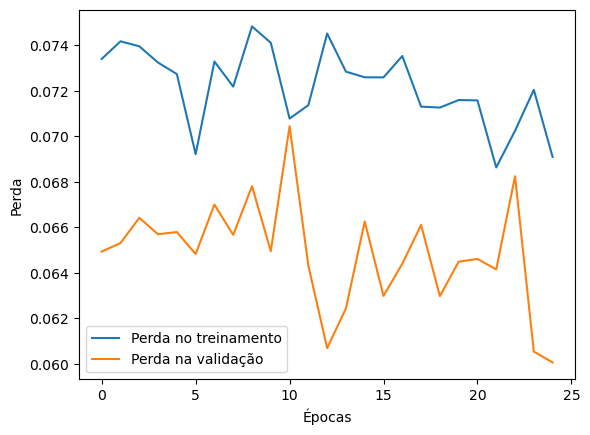

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Perda no treinamento')
plt.plot(history.history['val_loss'], label='Perda na validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


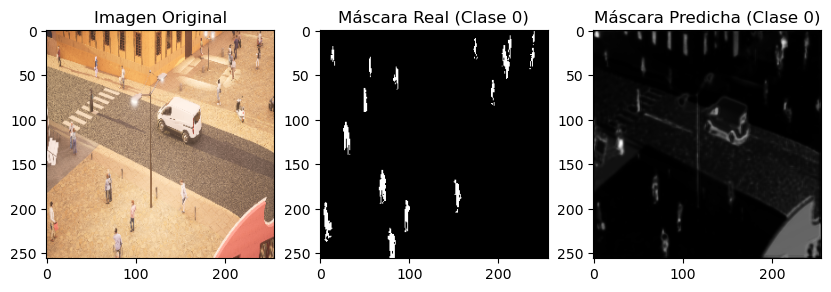

In [ ]:
import matplotlib.pyplot as plt

def visualize_multilabel_predictions(model, dataset):
    for img, mask in dataset.take(1):
        pred_mask = model.predict(tf.expand_dims(img[0], axis=0))[0]

        plt.figure(figsize=(10, 5))

        # Imagem original
        plt.subplot(1, 3, 1)
        plt.imshow(img[0].numpy())
        plt.title("Imagem Original")

        # Ver classe 0 real e prevista
        plt.subplot(1, 3, 2)
        plt.imshow(mask[0][:, :, 16], cmap='gray')
        plt.title("Máscara Real (Classe 0)")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask[:, :, 16], cmap='gray')
        plt.title("Máscara Prevista (Classe 0)")

        plt.show()
        break

visualize_multilabel_predictions(model, train_dataset)


# 2nd RETRAIN

In [11]:
# Carregar o modelo previamente treinado
model = tf.keras.models.load_model(
    'segmentation_model_v1_retrained_2025-01-27_06-39-03.h5', 
    custom_objects={'MeanIoU': tf.keras.metrics.MeanIoU}
)

print("Modelo carregado com sucesso.")
model.summary()

Modelo cargado exitosamente.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    524,544 │ up_sampling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_8[0][0],   │
│ (Concatenate)       │ 512)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │  1,179,904 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_9[0][0]  

 Total params: 7,698,452 (29.37 MB)

 Trainable params: 7,698,450 (29.37 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [34]:
# Configure um novo otimizador com uma taxa de aprendizado reduzida
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',  # Perda adequada para multilabel
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=22)]
)

# Defina o número adicional de épocas
EPOCHS_EXTRA = 50

history = model.fit(
    train_dataset,
    epochs=EPOCHS_EXTRA,
    validation_data=val_dataset,
    verbose=1
)

import datetime
# Obtenha a data e hora atuais no formato YYYY-MM-DD_HH-MM-SS
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Crie um nome de arquivo com data e hora atuais
model_filename = f'segmentation_model_v1_retrained{current_time}.h5'

# Salvar o modelo
model.save(model_filename)

print(f"Modelo salvo como: {model_filename}")

import json

history_filename = f'history_v1_retrained_{current_time}.json'

# Salve o histórico de treinamento como um arquivo JSON
with open(history_filename, 'w') as f:
    json.dump(history.history, f)

print(f"Histórico salvo como: {history_filename}")


Epoch 1/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3106s 20s/step - accuracy: 0.4354 - loss: 0.0660 - mean_io_u_1: 0.4644 - val_accuracy: 0.7585 - val_loss: 0.0407 - val_mean_io_u_1: 0.4547
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3084s 20s/step - accuracy: 0.4066 - loss: 0.0754 - mean_io_u_1: 0.4644 - val_accuracy: 0.7605 - val_loss: 0.0350 - val_mean_io_u_1: 0.4547
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3079s 19s/step - accuracy: 0.4190 - loss: 0.0717 - mean_io_u_1: 0.4644 - val_accuracy: 0.7541 - val_loss: 0.0385 - val_mean_io_u_1: 0.4549
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3096s 20s/step - accuracy: 0.4236 - loss: 0.0681 - mean_io_u_1: 0.4644 - val_accuracy: 0.7609 - val_loss: 0.0391 - val_mean_io_u_1: 0.4547
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3084s 20s/step - accuracy: 0.3889 - loss: 0.0775 - mean_io_u_1: 0.4644 - val_accuracy: 0.7583 - val_loss: 0.0403 - val_mean_io_u_1: 0.4549
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3086s 20s/step - accuracy: 0.4115 - loss: 0.0769 - mean_io_u_1: 0

Modelo guardado como: modelo_segmentacion_retrained_2025-01-27_06-39-03.h5
Historial guardado como: history_retrained_2025-01-27_06-39-03.json


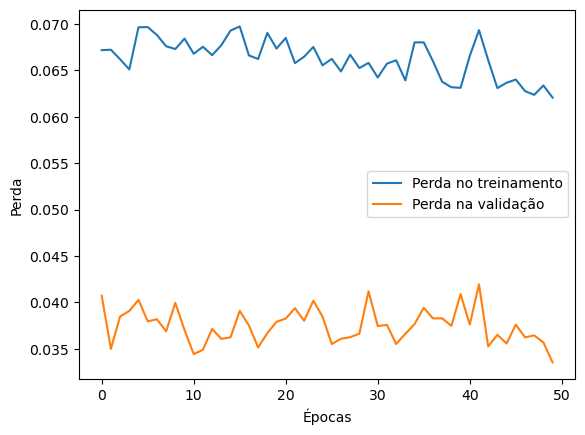

In [35]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Perda no treinamento')
plt.plot(history.history['val_loss'], label='Perda na validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


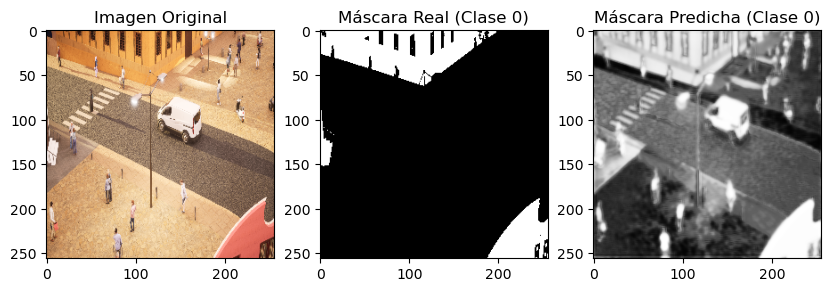

In [14]:
import matplotlib.pyplot as plt

def visualize_multilabel_predictions(model, dataset):
    for img, mask in dataset.take(1):
        pred_mask = model.predict(tf.expand_dims(img[0], axis=0))[0]

        plt.figure(figsize=(10, 5))

        # Imagem original
        plt.subplot(1, 3, 1)
        plt.imshow(img[0].numpy())
        plt.title("Imagem Original")

        # Ver classe 0 real e prevista
        plt.subplot(1, 3, 2)
        plt.imshow(mask[0][:, :, 16], cmap='gray')
        plt.title("Máscara Real (Classe 0)")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask[:, :, 16], cmap='gray')
        plt.title("Máscara Prevista (Classe 0)")

        plt.show()
        break

visualize_multilabel_predictions(model, train_dataset)